# K-Means Clustering

K-means is a suitable clustering method due to its simplicity, efficiency, and interpretability. 
- It is selected for its conceptual simplicity, speed and popularity (Turner et al., 2018), highlighting that it is both easy to implement and widely trusted. 
- In addition, it is a simple, fast algorithm that is computationally efficient (Turner et al., 2018), making it well-suited for large datasets such as galaxy surveys. 
- Furthermore, k-means produces interpretable results. In the research, the final centroids are cluster archetypes (Turner et al., 2018). This implies each cluster can be understood as a representative type of galaxy, which is particularly valuable for astronomical analysis.

In [17]:
import sys
import os
sys.path.append(os.path.abspath('..'))

# Data manipulation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#### Import Dataset

In [15]:
df = pd.read_csv("../astral_data.csv")
df.head()
df_features = df.iloc[:, :-1]
df_features.head()

,u-g,g-r,r-i,i-z,redshift_log
0,0.282719,0.199441,0.311683,0.203881,-0.145579
1,0.082746,0.183756,1.123312,0.428709,-0.549480
2,-0.312019,-0.067587,-0.128764,0.126954,-0.235675
3,0.397933,0.144873,0.426494,0.523488,-0.196892
4,-0.264895,-0.435012,-0.160010,-0.758546,-0.328149


#### Choice of K

- Elbow: Measures compactness (how tight clusters are)
- Sihouette score: Measures separation + cohesion (Compares how close points are to their own cluster vs other clusters)

Elbow alone is often ambiguous as there is no clear elbow, while sihouette alone can be misleading as it favours simpler structures. Hence, combining them gives a more robust decision.

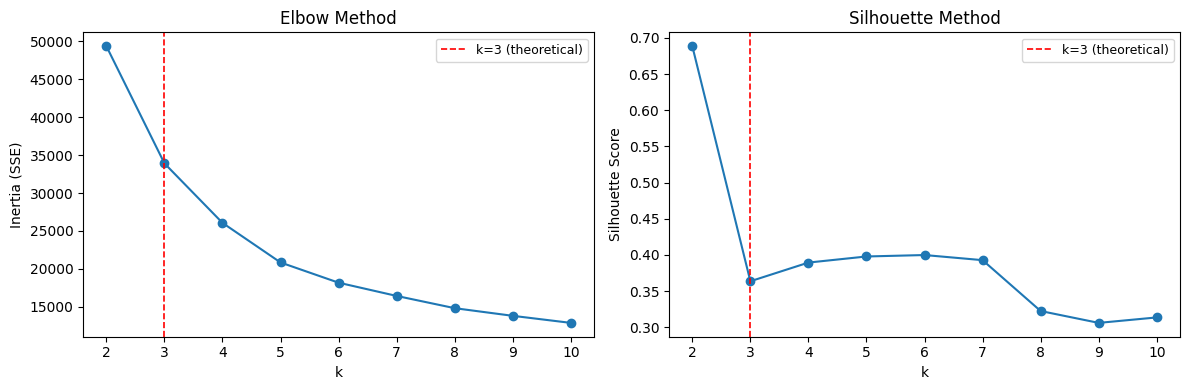

In [19]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_range = range(2, 11)

inertias = []
silhouettes = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_features)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(df_features, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Elbow plot
axes[0].plot(k_range, inertias, marker='o')
axes[0].axvline(x=3, color='red', linestyle='--', linewidth=1.2, label='k=3 (theoretical)')
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia (SSE)")
axes[0].set_title("Elbow Method")
axes[0].legend(fontsize=9)

# Silhouette plot
axes[1].plot(k_range, silhouettes, marker='o')
axes[1].axvline(x=3, color='red', linestyle='--', linewidth=1.2, label='k=3 (theoretical)')
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Method")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

Interpretation of results:

Elbow:
- No clean elbow: Inertia drops continuously and fairly smoothly from k = 2 to k = 10. The theoretical k=3 line sits at a relatively clear bend which gives moderate support for k = 3. Beyond k = 3, the gains diminish gradually.

Silhouette:
- The silhouette strongly prefers k=2, with k=3 as a secondary candidate. 

#### Cluster Stability for Optimal K

STACO measures solution stability. We ran 100 random initialisations to check how consistently K-Means produce the same clustering.  
- A Cramér's V near 1.0 means every random start converges to the same solution. 
- A lower score means different starts produce meaningfully different clusterings.

Clustering...
  k = 2
  k = 3
  k = 4
  k = 5
  k = 6
  k = 7
  k = 8
  k = 9
  k = 10
Done.
Labels saved.
Measuring stabilities...
  k = 2
  k = 3
  k = 4
  k = 5
  k = 6
  k = 7
  k = 8
  k = 9
  k = 10
Done.

staco shape: (900, 3)  (columns: stability, compactness, k)


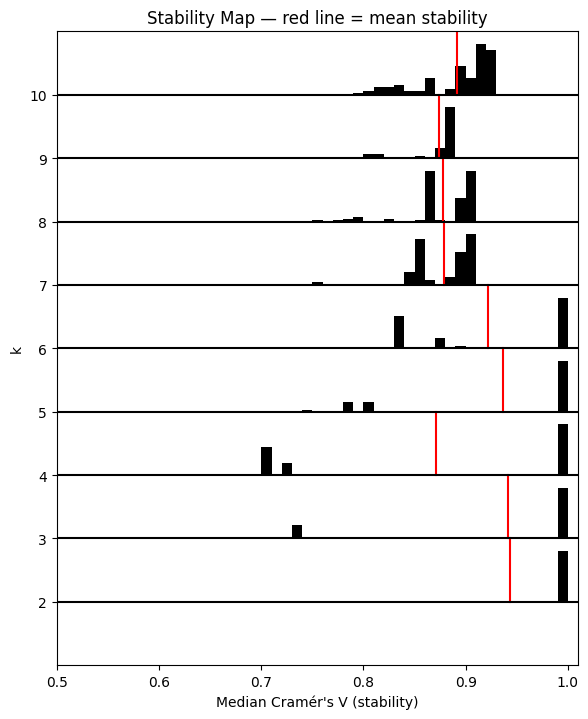

In [20]:
# Additional imports required by stacopy
import scipy.stats
import sklearn.metrics
import joblib
import os
import glob

def V(matrix):
    """
    Calculates Cramer's V index of association from a confusion matrix.
    Cramer's V ranges from 0 (no association) to 1 (perfect agreement).
    Use sklearn.metrics.confusion_matrix to set up a confusion matrix.
    """
    chi = scipy.stats.chi2_contingency(matrix)[0]
    n = matrix.sum()
    return np.sqrt(chi / (n * (min(matrix.shape) - 1)))


def STACOK(data, k):
    """
    Runs k-means once for input data at input k.
    Returns labels (array) and compactness (inertia).
    """
    kmrun = KMeans(
        n_clusters=k,
        max_iter=data.shape[0],
        n_init=1,
        tol=0,
        init='k-means++',
        random_state=None
    ).fit(data)
    return kmrun.predict(data), kmrun.inertia_


def STACOV(lbls, i):
    """
    Calculates median Cramer's V for the ith solution w.r.t. all other
    solutions at the same k. Higher = more stable/consistent.

    Args:
        lbls: (n_obs, init) array of cluster labels for all solutions at one k
        i:    index of the solution to evaluate
    Returns:
        Median Cramer's V across all pairwise comparisons
    """
    lbls_others = np.delete(lbls, i, axis=1)
    cvind = np.zeros((lbls_others.shape[1], 1))
    for q in range(lbls_others.shape[1]):
        cvind[q, 0] = V(sklearn.metrics.confusion_matrix(lbls[:, i], lbls_others[:, q]))
    return np.median(cvind)


def STACO(data, k=range(2, 11), init=100, save_lbls=False):
    """
    Runs stacopy: calculates stabilities and compactnesses for `init` solutions
    at each value of k.

    Args:
        data:      (n_obs, n_features) array — clustering features only,
                   no IDs or flags. Data should already be scaled/normalised.
        k:         iterable of k values to evaluate (default: range(2, 11))
        init:      number of k-means initialisations per k (default: 100)
        save_lbls: if True, saves label arrays to 'lbls_k{k}.txt' files

    Returns:
        (init*len(k), 3) array with columns:
            [0] stability  — median Cramer's V
            [1] compactness — k-means inertia (phi)
            [2] k           — value of k
    """
    obs, feats = data.shape
    nk = len(k)
    k = list(k)

    lbls = np.zeros((obs, init, nk))
    phi  = np.zeros((init, nk))

    print("Clustering...")
    for j in range(nk):
        print(f"  k = {k[j]}")
        l, p = zip(*joblib.Parallel(n_jobs=-1, mmap_mode='w+')(
            joblib.delayed(STACOK)(data, k[j]) for i in range(init)
        ))
        lbls[:, :, j] = np.transpose(np.array(l))
        phi[:, j]     = np.transpose(np.array(p))
    print("Done.")

    if save_lbls:
        for j in range(nk):
            np.savetxt(f'lbls_k{k[j]}.txt', lbls[:, :, j], delimiter=',')
        print("Labels saved.")

    cvmed = np.zeros((init, nk))

    print("Measuring stabilities...")
    for j in range(nk):
        print(f"  k = {k[j]}")
        cvmed[:, j] = joblib.Parallel(n_jobs=-1, mmap_mode='w+')(
            joblib.delayed(STACOV)(lbls[:, :, j], i) for i in range(init)
        )
    print("Done.")

    cvmed = cvmed.flatten('F').reshape(-1, 1)
    phi   = phi.flatten('F').reshape(-1, 1)
    k_arr = (np.ones((init, 1)) * k).flatten('F').reshape(-1, 1)

    return np.hstack((cvmed, phi, k_arr))

# Run Stacopy on data
k    = range(2, 11)  # candidate k values to evaluate
init = 100            # number of k-means runs per k (use 100 for final analysis)

data = np.array(df_features)  # ensure numpy array

lbls_dict = {}  # store labels in memory instead of disk

if __name__ == '__main__':
    staco = STACO(data, k=k, init=init, save_lbls=True)  # let it save temporarily

    # Read all saved label files into memory, then delete them
    for ki in k:
        fname = f'lbls_k{ki}.txt'
        if os.path.exists(fname):
            lbls_dict[ki] = np.genfromtxt(fname, delimiter=',')
            os.remove(fname)  # delete after reading

    # Also clean up staco results file
    if os.path.exists('staco_results.txt'):
        staco = np.genfromtxt('staco_results.txt', delimiter=',')
        os.remove('staco_results.txt')

    print(f"\nstaco shape: {staco.shape}  (columns: stability, compactness, k)")

# Plot stability map
fig, ax = plt.subplots(figsize=(6, 0.7 * len(k) + 1))

for i in k:
    cvs = staco[staco[:, 2] == i, 0].reshape(-1, 1)

    hist, bins = np.histogram(cvs, bins=np.arange(0.0, 1.01, 0.01))
    hist = (hist.astype(float) / float(max(hist))) * 0.8

    ax.plot([0.0, 1.01], [i, i], c='k', ls='-', lw=1.5, zorder=3)
    ax.bar(bins[1:] - 0.005, hist, width=0.01, bottom=i, color='k')
    ax.plot([np.mean(cvs), np.mean(cvs)], [i, i + 1], 'r-', lw=1.5)

ax.set(
    yticks=list(k),
    xlim=(0.5, 1.01),
    ylim=(min(k) - 1, max(k) + 1),
    xlabel='Median Cramér\'s V (stability)',
    ylabel='k'
)
ax.set_title('Stability Map — red line = mean stability')
plt.tight_layout()
plt.show()

The STACO stability analysis indicates k=2 and k = 3 results in the most stable solutions, with a median Cramer's V of almost 1.0

Hence, we will further investigate the following choices of k for Set A:

- k=2: Dominant signal. Both silhouette and stability agree, likely reflecting a stars vs. extragalactic split rather than the full QSO/star/galaxy separation.
- k=3: Physical prior that is worth investigating

### K-Means Evaluation (K=2, K=3)

In [25]:
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                             calinski_harabasz_score, silhouette_samples,
                             adjusted_rand_score, normalized_mutual_info_score)
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA

# ── 0. Setup ──────────────────────────────────────────────────────────────────
le     = LabelEncoder()
y_true = le.fit_transform(df.iloc[:,-1])

pca  = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(df_features)
ev   = pca.explained_variance_ratio_

class_colors    = {"GALAXY": "#378ADD", "QSO": "#EF9F27", "STAR": "#1D9E75"}
cluster_colors  = ["#E24B4A", "#378ADD", "#1D9E75", "#EF9F27"]
k_values        = [2, 3]

# ── 1. Fit, evaluate, and store results for each k ───────────────────────────
results = {}

for k in k_values:
    km     = KMeans(n_clusters=k, random_state=42, n_init=25)
    labels = km.fit_predict(df_features)

    sil = silhouette_score(df_features, labels)
    db  = davies_bouldin_score(df_features, labels)
    ch  = calinski_harabasz_score(df_features, labels)
    ari = adjusted_rand_score(y_true, labels)
    nmi = normalized_mutual_info_score(y_true, labels)

    ct          = pd.crosstab(labels, y_true, rownames=["cluster"], colnames=["true class"])
    ct.columns  = le.classes_
    sil_vals    = silhouette_samples(df_features, labels)

    results[k] = dict(labels=labels, sil=sil, db=db, ch=ch,
                      inertia=km.inertia_, ari=ari, nmi=nmi,
                      ct=ct, sil_vals=sil_vals)

# ── 2. Summary metrics table ──────────────────────────────────────────────────
print(f"{'k':<4} {'Silhouette':>10} {'Davies-Bouldin':>15} {'Calinski-H':>12} {'Inertia':>12} {'ARI':>8} {'NMI':>8}")
print("-" * 75)
for k in k_values:
    r = results[k]
    print(f"{k:<4} {r['sil']:>10.4f} {r['db']:>15.4f} {r['ch']:>12.2f} {r['inertia']:>12.2f} {r['ari']:>8.4f} {r['nmi']:>8.4f}")

# ── 3. Crosstab and per-cluster purity for each k ────────────────────────────
for k in k_values:
    r  = results[k]
    ct = r["ct"]
    print(f"\n{'='*50}")
    print(f"k = {k}  |  Cluster × True Class")
    print('='*50)
    print(ct.to_string())
    print()
    for cl in np.unique(r["labels"]):
        dominant       = ct.loc[cl].idxmax()
        cluster_purity = ct.loc[cl].max() / ct.loc[cl].sum()
        n              = (r["labels"] == cl).sum()
        print(f"  Cluster {cl} → {dominant:8s}  ({cluster_purity*100:.1f}% pure, n={n})")

k    Silhouette  Davies-Bouldin   Calinski-H      Inertia      ARI      NMI
---------------------------------------------------------------------------
2        0.6887          0.5287      7292.12     49368.60   0.5935   0.6355
3        0.3636          0.8935      7525.93     33909.04   0.2062   0.3970

k = 2  |  Cluster × True Class
         GALAXY  QSO  STAR
cluster                   
0          8412  685     1
1            11    0   624

  Cluster 0 → GALAXY    (92.5% pure, n=9098)
  Cluster 1 → STAR      (98.3% pure, n=635)

k = 3  |  Cluster × True Class
         GALAXY  QSO  STAR
cluster                   
0             4    0   624
1          4859   51     1
2          3560  634     0

  Cluster 0 → STAR      (99.4% pure, n=628)
  Cluster 1 → GALAXY    (98.9% pure, n=4911)
  Cluster 2 → GALAXY    (84.9% pure, n=4194)


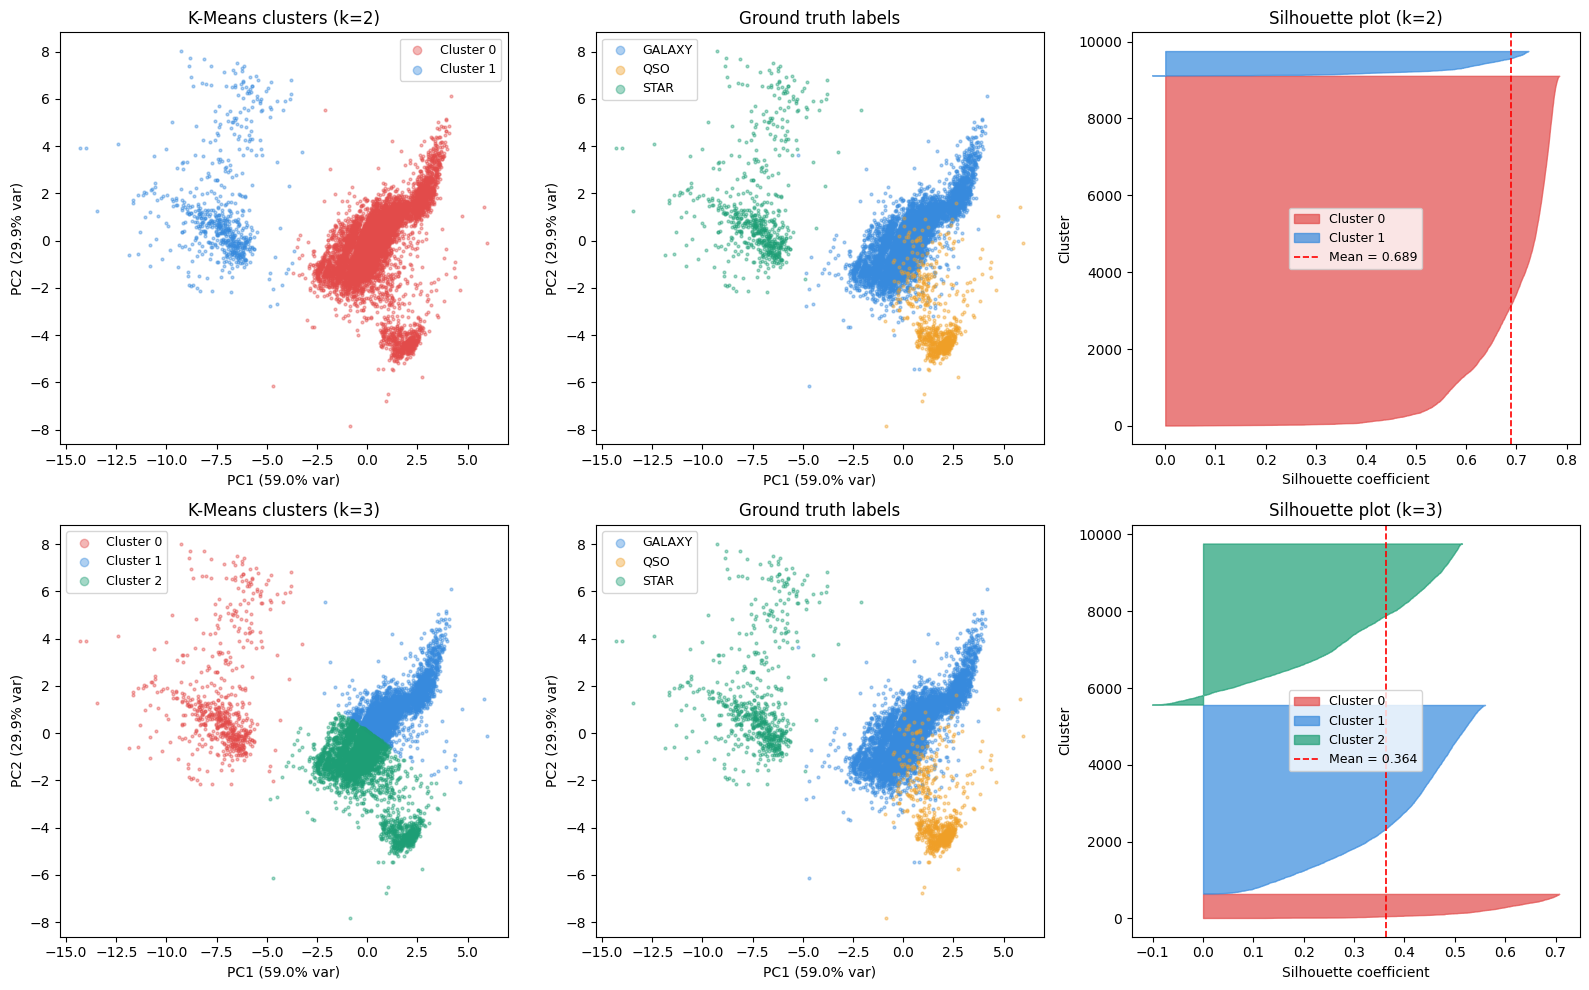

In [27]:
# ── 4. Plots: one row per k ───────────────────────────────────────────────────
fig, axes = plt.subplots(len(k_values), 3, figsize=(16, 5 * len(k_values)))

for row, k in enumerate(k_values):
    r      = results[k]
    labels = r["labels"]
    cols   = cluster_colors[:k]

    # Panel 1: cluster assignments
    ax = axes[row, 0]
    for i, cl in enumerate(np.unique(labels)):
        mask = labels == cl
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   s=4, alpha=0.4, color=cols[i], label=f"Cluster {cl}")
    ax.set_title(f"K-Means clusters (k={k})")
    ax.set_xlabel(f"PC1 ({ev[0]*100:.1f}% var)")
    ax.set_ylabel(f"PC2 ({ev[1]*100:.1f}% var)")
    ax.legend(markerscale=3, fontsize=9)

    # Panel 2: ground truth (same every row but useful for direct comparison)
    ax = axes[row, 1]
    for cls_name, col in class_colors.items():
        mask = df["class"] == cls_name
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   s=4, alpha=0.4, color=col, label=cls_name)
    ax.set_title(f"Ground truth labels")
    ax.set_xlabel(f"PC1 ({ev[0]*100:.1f}% var)")
    ax.set_ylabel(f"PC2 ({ev[1]*100:.1f}% var)")
    ax.legend(markerscale=3, fontsize=9)

    # Panel 3: silhouette plot
    ax      = axes[row, 2]
    y_lower = 10
    for i, cl in enumerate(np.unique(labels)):
        cl_sil  = np.sort(r["sil_vals"][labels == cl])
        y_upper = y_lower + cl_sil.shape[0]
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cl_sil,
                         alpha=0.7, color=cols[i], label=f"Cluster {cl}")
        y_lower = y_upper + 10
    ax.axvline(x=r["sil"], color="red", linestyle="--", linewidth=1.2,
               label=f"Mean = {r['sil']:.3f}")
    ax.set_title(f"Silhouette plot (k={k})")
    ax.set_xlabel("Silhouette coefficient")
    ax.set_ylabel("Cluster")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

Set A Conclusions

k=2: QSO vs. Everything
- The split is QSO vs. everything else, with all 625 stars are absorbed into the galaxy cluster (Cluster 0, 90.5% pure). 
- Metrics are strong, but the clustering is physically uninformative for a three-class problem. 
- The PCA structure forms a broad triangular/fan shape, with PC1 capturing 76.1% of variance, suggesting the feature set compresses variance efficiently into a dominant axis that separates QSOs cleanly.

k=3: Third cluster splits galaxies, not stars
- The third cluster does not isolate stars. Instead k=3, splits the galaxy population into two subgroups while Cluster 2 captures QSOs at 100% purity. The 625 stars are distributed across Clusters 0 and 1 with no dedicated star cluster emerging. 
- The silhouette plot shows Cluster 1 with a wide spread of low values, confirming this is a geometrically forced split rather than a natural boundary, while the ARI of 0.322 indicates only modest alignment with true labels.

K-Means finds two natural structures in this feature set: QSOs and a broad non-QSO population. Stars and galaxies occupy overlapping regions in PCA space and cannot be separated by K-Means. Recovering all three physical classes will require either additional discriminating features or a different algorithm better suited to overlapping, non-spherical cluster geometries.